### Przedstawienie średniego NO2 godzinowego w latach 2015-2024

Godzina,Srednie_NO2
0,38.98
1,32.45
2,27.66
3,25.21
4,25.18
5,29.07
6,37.68
7,46.57
8,51.09
9,51.22


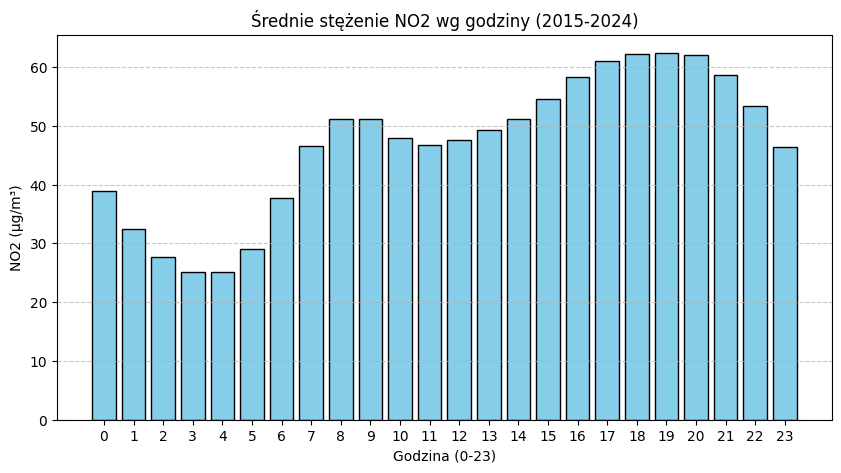

In [0]:
from pyspark.sql.functions import hour, avg, round
import matplotlib.pyplot as plt

silver_no2 = spark.read.table("silver_no2_warsaw")

gold_hourly = silver_no2 \
    .groupBy(hour("Data_Czas").alias("Godzina")) \
    .agg(round(avg("NO2_Wartosc"), 2).alias("Srednie_NO2")) \
    .orderBy("Godzina")

gold_hourly.write.format("delta").mode("overwrite").saveAsTable("gold_hourly_profile")
display(gold_hourly)

df_hourly = gold_hourly.toPandas()

plt.figure(figsize=(10, 5))
plt.bar(df_hourly['Godzina'], df_hourly['Srednie_NO2'], color='skyblue', edgecolor='black')
plt.title("Średnie stężenie NO2 wg godziny (2015-2024)")
plt.xlabel("Godzina (0-23)")
plt.ylabel("NO2 (µg/m³)")
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Przedstawienie średniego stężenia NO2 w poszczególnych miesiącach 2023 roku

Miesiac,Srednie_NO2
1,33.4
2,39.95
3,46.62
4,38.58
5,40.4
6,48.86
7,51.64
8,51.84
9,56.41
10,38.22


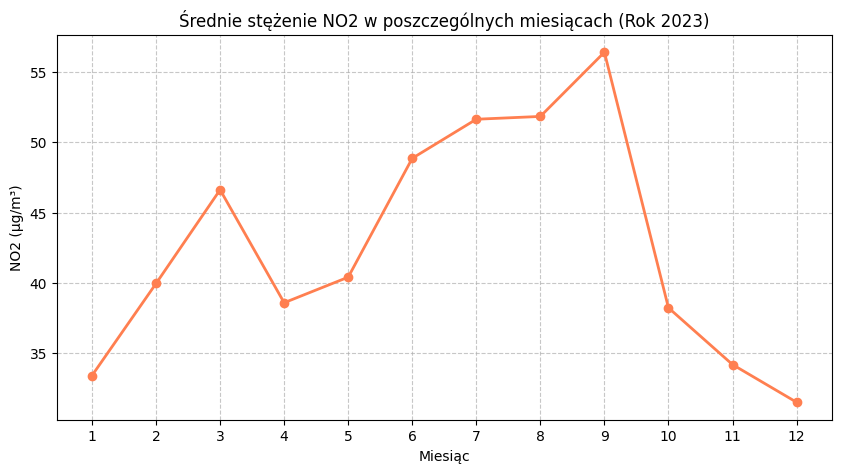

In [0]:
from pyspark.sql.functions import month, year, avg, round
import matplotlib.pyplot as plt

silver_no2 = spark.read.table("silver_no2_warsaw")

gold_monthly_2023 = silver_no2 \
    .filter(year("Data_Czas") == 2023) \
    .groupBy(month("Data_Czas").alias("Miesiac")) \
    .agg(round(avg("NO2_Wartosc"), 2).alias("Srednie_NO2")) \
    .orderBy("Miesiac")

gold_monthly_2023.write.format("delta").mode("overwrite").saveAsTable("gold_monthly_profile")
display(gold_monthly_2023)

df_monthly = gold_monthly_2023.toPandas()

plt.figure(figsize=(10, 5))
plt.plot(df_monthly['Miesiac'], df_monthly['Srednie_NO2'], marker='o', color='coral', linewidth=2)
plt.title("Średnie stężenie NO2 w poszczególnych miesiącach (Rok 2023)")
plt.xlabel("Miesiąc")
plt.ylabel("NO2 (µg/m³)")
plt.xticks(range(1, 13))
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Główny wykres - przedstawienie malejącego trendu średniego rocznego stężenia NO2 w powietrzu względem rosnącego trendu udziału samochodów elektrycznych i hybrydowych w populacji samochodów mieszkańców Warszawy

Główny zbiór analityczny gotowy!


Rok,Srednie_Roczne_NO2,Osobowe_Ogolem,Osobowe_Pozostale,Procent_Nowoczesnej_Floty
2015,59.27,1131120,7533,0.67
2016,56.71,1194068,9405,0.79
2017,51.65,1261803,15372,1.22
2018,50.31,1332923,26033,1.95
2019,49.68,1393218,44126,3.17
2020,37.17,1425475,61706,4.33
2021,42.93,1460479,92230,6.32
2022,41.17,1518315,127818,8.42
2023,42.65,1574854,168607,10.71
2024,38.24,1336242,184940,13.84


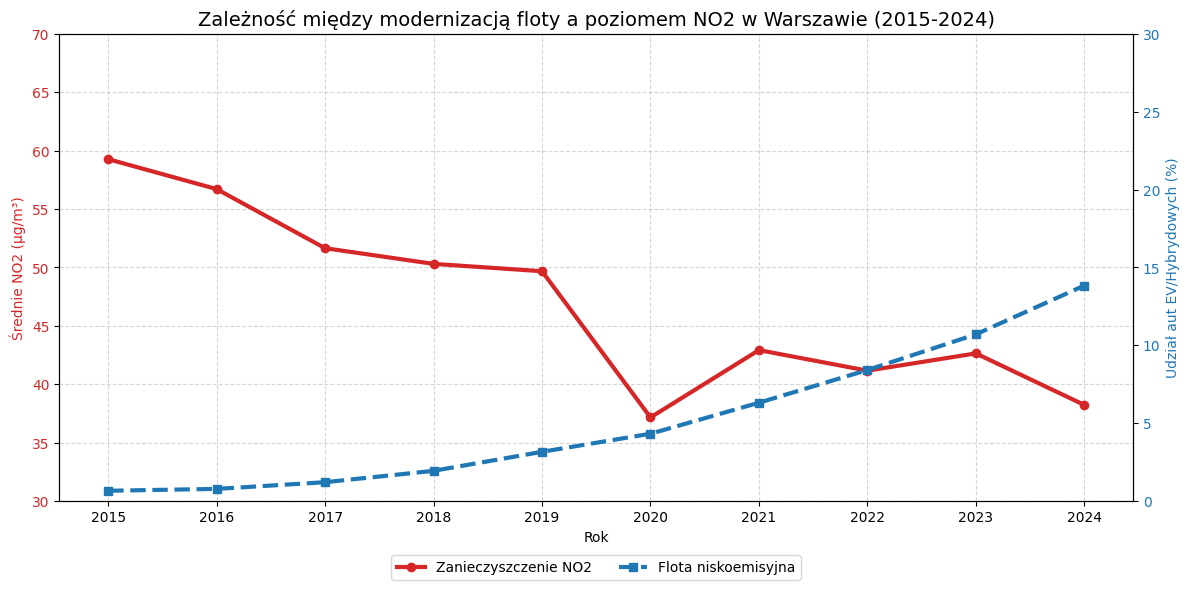

In [0]:
from pyspark.sql.functions import year, avg, round
import matplotlib.pyplot as plt

silver_no2 = spark.read.table("silver_no2_warsaw")
silver_cars = spark.read.table("silver_cars_warsaw")

gold_yearly_no2 = silver_no2 \
    .groupBy(year("Data_Czas").alias("Rok")) \
    .agg(round(avg("NO2_Wartosc"), 2).alias("Srednie_Roczne_NO2"))

gold_final_trend = gold_yearly_no2 \
    .join(silver_cars, "Rok") \
    .orderBy("Rok")

gold_final_trend.write.format("delta").mode("overwrite").saveAsTable("gold_yearly_trend")
print("Główny zbiór analityczny gotowy!")
display(gold_final_trend)

df_plot = gold_final_trend.toPandas() 

fig, ax1 = plt.subplots(figsize=(12, 6))

color1 = 'tab:red'
ax1.set_xlabel('Rok')
ax1.set_ylabel('Średnie NO2 (µg/m³)', color=color1)
ax1.plot(df_plot['Rok'], df_plot['Srednie_Roczne_NO2'], marker='o', color=color1, linewidth=3, label="Zanieczyszczenie NO2")
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_xticks(df_plot['Rok'])
ax1.grid(True, linestyle='--', alpha=0.5)

ax1.set_ylim(30, 70) 

ax2 = ax1.twinx()  
color2 = 'tab:blue'
ax2.set_ylabel('Udział aut EV/Hybrydowych (%)', color=color2)
ax2.plot(df_plot['Rok'], df_plot['Procent_Nowoczesnej_Floty'], marker='s', color=color2, linewidth=3, linestyle='--', label="Flota niskoemisyjna")
ax2.tick_params(axis='y', labelcolor=color2)

ax2.set_ylim(0, 30)

plt.title("Zależność między modernizacją floty a poziomem NO2 w Warszawie (2015-2024)", fontsize=14)

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2)

fig.tight_layout()  
plt.show()